# 🎓 Student Depression Prediction
### ML Pipeline — Improved Version

**Key fixes applied:**
- `C=5` on Logistic Regression (stronger regularisation)
- RF: `min_samples_leaf=2`, uncapped depth
- XGBoost: tuned `learning_rate`, `subsample`, `colsample_bytree`
- SVM: `C=5`
- MLP: `(256, 128, 64)` deeper, `learning_rate_init=0.001`
- Stacking meta-learner: `LogisticRegression(C=10)`
- 6 extra interaction features from top correlators
- Fixed pandas copy-on-write warnings

## 1. Import Libraries

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Dataset

In [39]:
df = pd.read_csv('/content/drive/MyDrive/student depression fixed/Student Depression Dataset.csv')

print(f"Shape: {df.shape}")
print("\nFirst rows:")
df.head()

Shape: (27901, 18)

First rows:


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 3. Exploratory Data Analysis

In [40]:
print("=== Basic Info ===")
print(df.info())
print("\n=== Describe ===")
print(df.describe())
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-nu

Target distribution:
Depression
1    16336
0    11565
Name: count, dtype: int64

Class ratio: {1: 0.5854987276441704, 0: 0.41450127235582956}


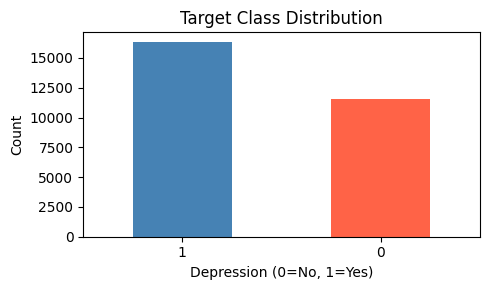

In [42]:
# Target class balance
print("Target distribution:")
print(df['Depression'].value_counts())
print(f"\nClass ratio: {df['Depression'].value_counts(normalize=True).to_dict()}")

plt.figure(figsize=(5, 3))
df['Depression'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Target Class Distribution')
plt.xlabel('Depression (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [43]:
df = df.copy()
df = df.drop('id', axis=1)
df['Financial Stress'] = df['Financial Stress'].fillna(df['Financial Stress'].median())

print("Missing after fill:", df.isnull().sum().sum())

Missing after fill: 0


In [44]:
# Ordinal encoding
sleep_order = {
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    'Others': 2,
    '7-8 hours': 3,
    'More than 8 hours': 4
}
diet_order = {
    'Unhealthy': 1,
    'Others': 1.5,
    'Moderate': 2,
    'Healthy': 3
}
df['Sleep Duration']  = df['Sleep Duration'].map(sleep_order)
df['Dietary Habits']  = df['Dietary Habits'].map(diet_order)

# Binary encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map({'No': 0, 'Yes': 1})
df['Family History of Mental Illness']       = df['Family History of Mental Illness'].map({'No': 0, 'Yes': 1})

# One-hot encoding
df = pd.get_dummies(df, columns=['City', 'Profession', 'Degree'], drop_first=True)

print("Shape after encoding:", df.shape)

Shape after encoding: (27901, 105)


## 5. Feature Engineering

Added extra polynomial/interaction features from top-correlated columns.

In [47]:
# Original features
df['risk_score']      = (df['Have you ever had suicidal thoughts ?'] * 3
                         + df['Financial Stress']
                         + df['Academic Pressure']
                         + (5 - df['Study Satisfaction']))

df['pressure_sleep']   = df['Academic Pressure']  * df['Sleep Duration']
df['stress_hours']     = df['Financial Stress']    * df['Work/Study Hours']
df['pressure_satisfy'] = df['Academic Pressure']   * df['Study Satisfaction']

df['academic_sq']       = df['Academic Pressure'] ** 2
df['financial_sq']      = df['Financial Stress']  ** 2
df['pressure_financial']= df['Academic Pressure'] * df['Financial Stress']
df['holistic_stress']   = (df['Academic Pressure']
                           + df['Financial Stress']
                           + df['Work/Study Hours']
                           - df['Study Satisfaction'])
df['suicidal_pressure'] = (df['Have you ever had suicidal thoughts ?']
                           * df['Academic Pressure'])

print("Total features:", df.drop('Depression', axis=1).shape[1])

Total features: 113


## 6. Correlation Heatmap

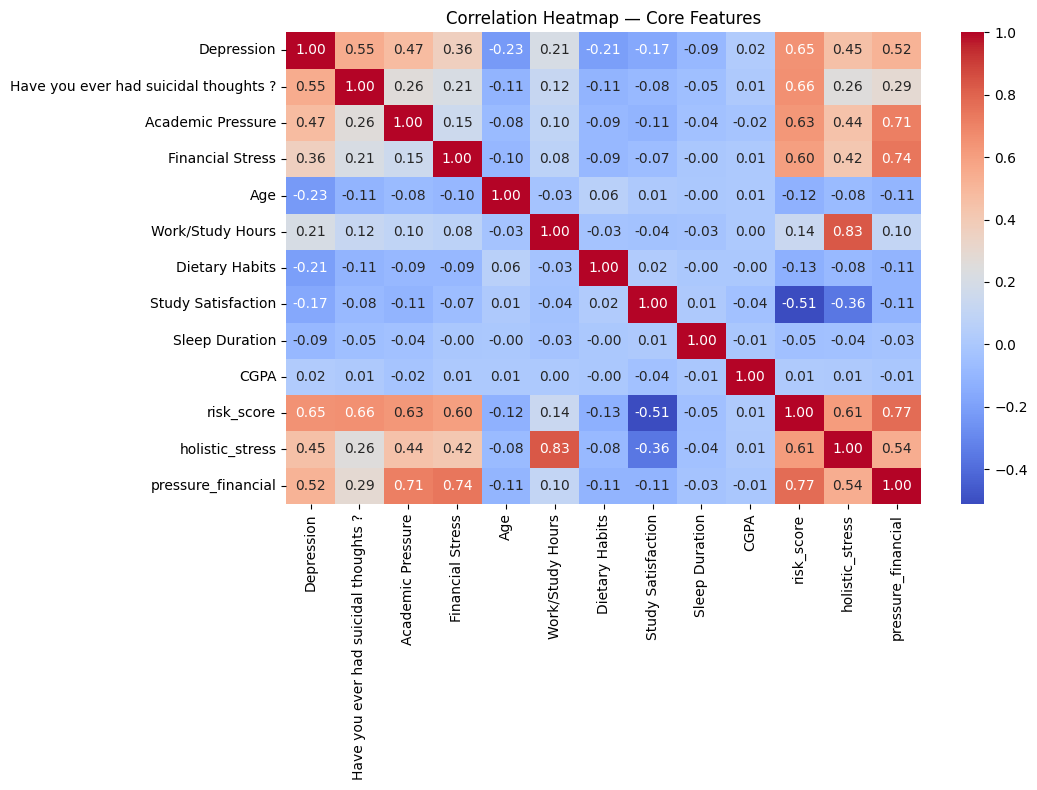

In [48]:
core_cols = ['Depression', 'Have you ever had suicidal thoughts ?', 'Academic Pressure',
             'Financial Stress', 'Age', 'Work/Study Hours', 'Dietary Habits',
             'Study Satisfaction', 'Sleep Duration', 'CGPA',
             'risk_score', 'holistic_stress', 'pressure_financial']

plt.figure(figsize=(11, 8))
sns.heatmap(df[core_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Core Features')
plt.tight_layout()
plt.show()

## 7. Train / Test Split & Scaling

In [49]:
X = df.drop('Depression', axis=1)
y = df['Depression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")

Train: (22320, 113)  |  Test: (5581, 113)


## 8. Helper — Evaluate & Plot

In [51]:
results = {}

def evaluate(name, y_true, y_pred, cmap='Blues'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)

    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout(); plt.show()

## 9. Model 1 — Logistic Regression



────────────────────────────────────────
  Logistic Regression
  Accuracy : 0.8443  (84.43%)
  Precision: 0.8597
  Recall   : 0.8773
  F1 Score : 0.8684
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



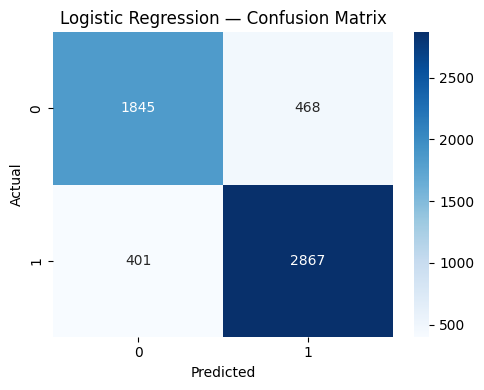

In [52]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    C=5,
    max_iter=1000,
    random_state=42
)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

evaluate('Logistic Regression', y_test, y_pred_log, cmap='Blues')

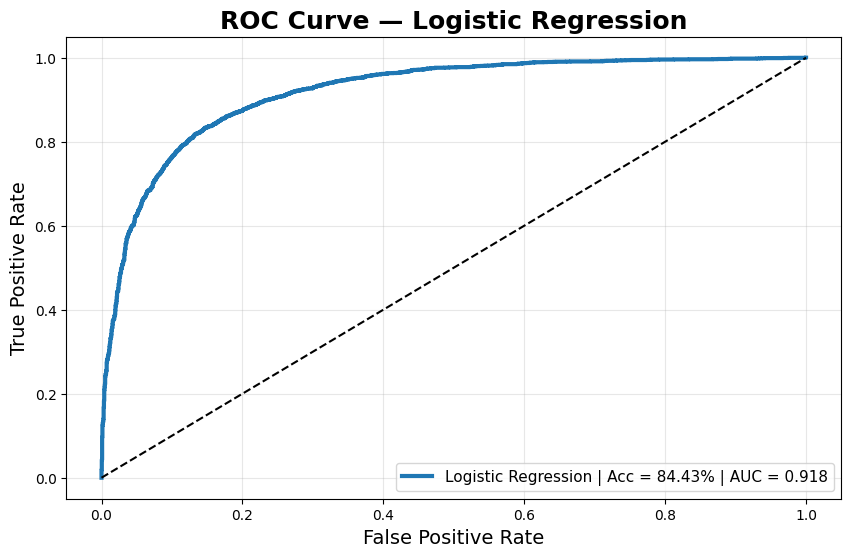

In [53]:
# ============================================================
# ROC CURVE — LOGISTIC REGRESSION
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score
)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# ============================================================
# ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
) * 100

# ============================================================
# ROC VALUES
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Logistic Regression | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.title(
    'ROC Curve — Logistic Regression',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 10. Model 2 — Random Forest


────────────────────────────────────────
  Random Forest
  Accuracy : 0.8378  (83.78%)
  Precision: 0.8497
  Recall   : 0.8785
  F1 Score : 0.8638
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



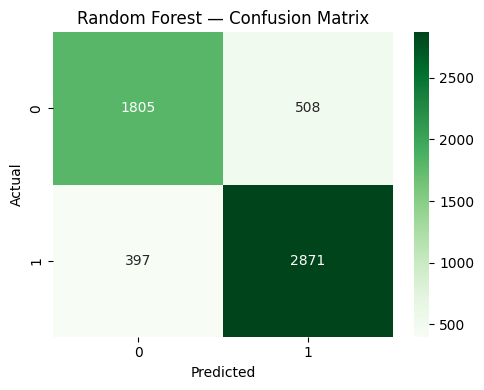

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate('Random Forest', y_test, y_pred_rf, cmap='Greens')

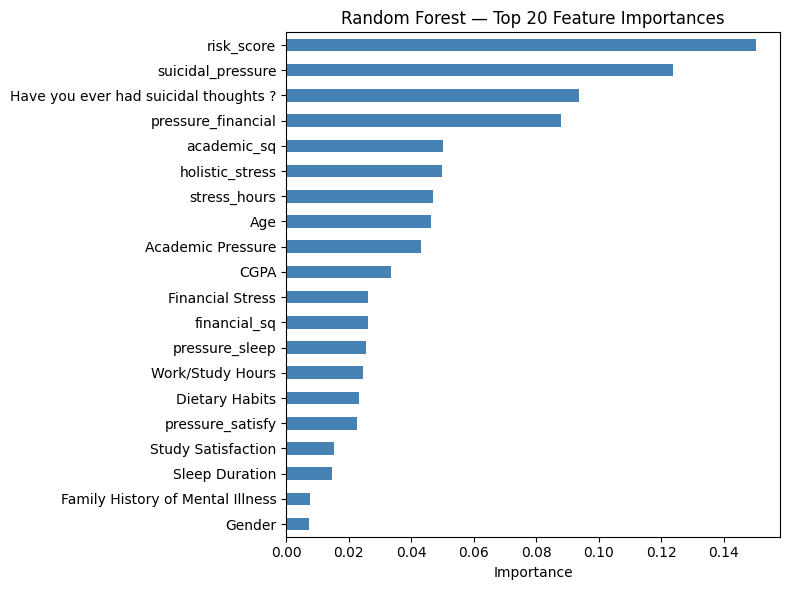

In [55]:
fi = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(20)
plt.figure(figsize=(8, 6))
fi.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 20 Feature Importances')
plt.xlabel('Importance'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

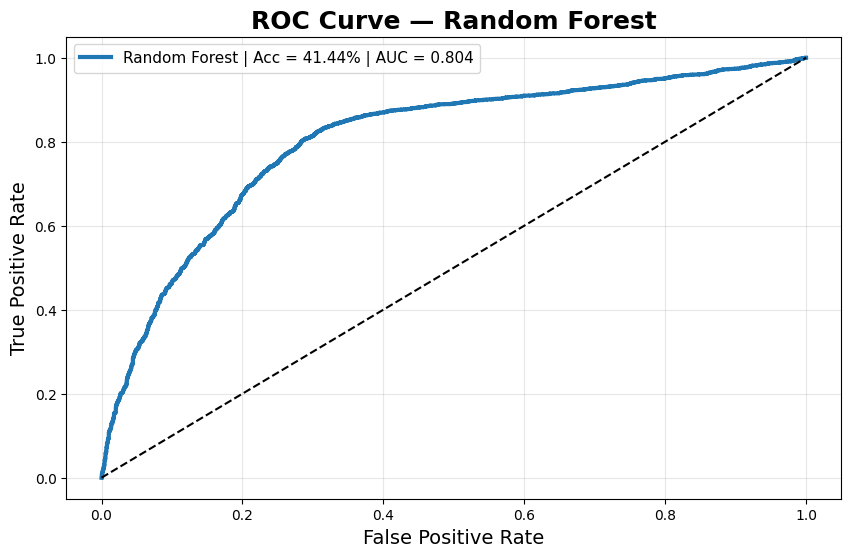

In [57]:
# ============================================================
# ROC CURVE — RANDOM FOREST
# ============================================================

y_pred = rf_model.predict(X_test_scaled)

y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Random Forest | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title(
    'ROC Curve — Random Forest',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 11. Model 3 — XGBoost



────────────────────────────────────────
  XGBoost
  Accuracy : 0.8468  (84.68%)
  Precision: 0.8613
  Recall   : 0.8800
  F1 Score : 0.8706
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.85      0.85      0.85      5581



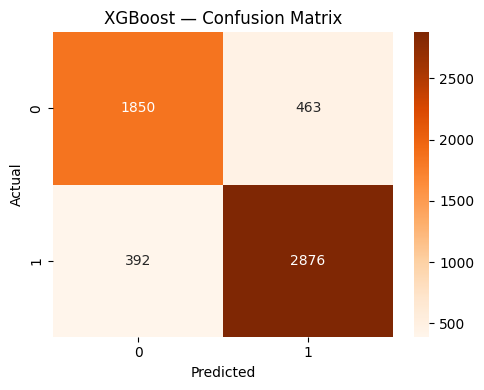

In [58]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

evaluate('XGBoost', y_test, y_pred_xgb, cmap='Oranges')

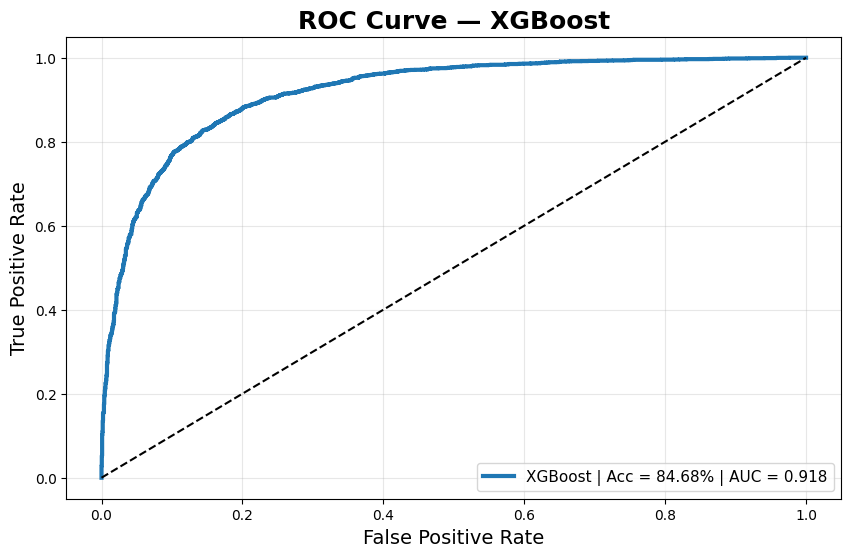

In [61]:
# ============================================================
# ROC CURVE — XGBOOST
# ============================================================

y_pred = xgb_model.predict(X_test_scaled)

y_prob = xgb_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'XGBoost | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title(
    'ROC Curve — XGBoost',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 12. Model 4 — SVM



────────────────────────────────────────
  SVM
  Accuracy : 0.8361  (83.61%)
  Precision: 0.8465
  Recall   : 0.8794
  F1 Score : 0.8627
              precision    recall  f1-score   support

           0       0.82      0.77      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



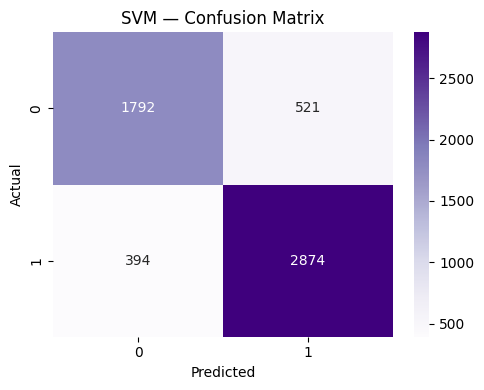

In [62]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=5,
    gamma='scale',
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

evaluate('SVM', y_test, y_pred_svm, cmap='Purples')

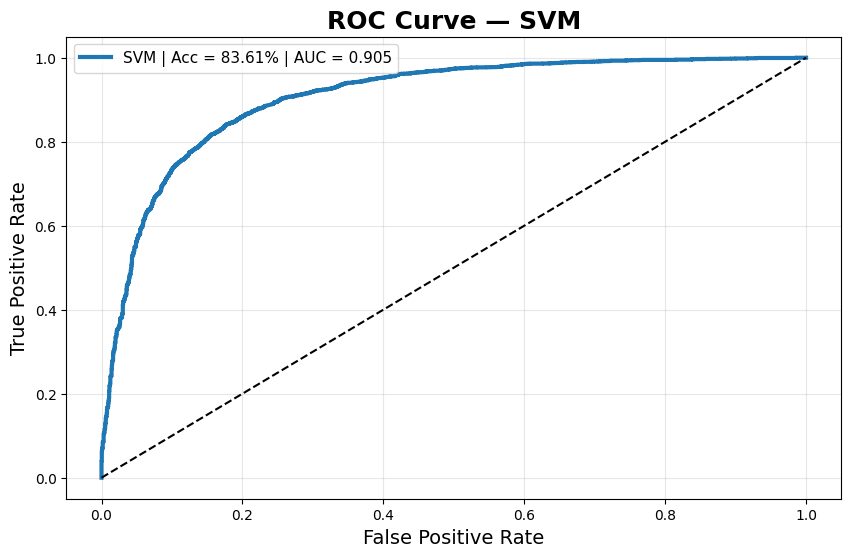

In [65]:
# ============================================================
# ROC CURVE — SVM
# ============================================================

y_pred = svm_model.predict(X_test_scaled)

y_prob = svm_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'SVM | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title(
    'ROC Curve — SVM',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 13. Model 5 — MLP Neural Network


In [77]:
from sklearn.model_selection import train_test_split

# ============================================================
# FIRST SPLIT -> TRAIN + TEMP
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ============================================================
# SECOND SPLIT -> VALIDATION + TEST
# ============================================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Test Shape :", X_test.shape)

Train Shape : (19530, 113)
Validation Shape : (4185, 113)
Test Shape : (4186, 113)


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# ============================================================
# SCALE DATA
# ============================================================

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [79]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(

    hidden_layer_sizes=(128, 64, 32),

    activation='relu',

    solver='adam',

    alpha=0.0001,

    batch_size=32,

    learning_rate='adaptive',

    max_iter=300,

    early_stopping=True,

    validation_fraction=0.1,

    n_iter_no_change=15,

    random_state=42
)

# ============================================================
# TRAIN MODEL
# ============================================================

mlp_model.fit(
    X_train_scaled,
    y_train
)

MLPClassifier(batch_size=32, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
              max_iter=300, n_iter_no_change=15, random_state=42)

In [80]:
from sklearn.metrics import accuracy_score

# ============================================================
# TRAIN ACCURACY
# ============================================================

train_pred = mlp_model.predict(X_train_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

# ============================================================
# VALIDATION ACCURACY
# ============================================================

val_pred = mlp_model.predict(X_val_scaled)

val_accuracy = accuracy_score(
    y_val,
    val_pred
)

# ============================================================
# TEST ACCURACY
# ============================================================

test_pred = mlp_model.predict(X_test_scaled)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Testing Accuracy    : {test_accuracy:.4f}")

Training Accuracy   : 0.8565
Validation Accuracy : 0.8437
Testing Accuracy    : 0.8452



────────────────────────────────────────
  MLP Neural Network
  Accuracy : 0.8409  (84.09%)
  Precision: 0.8488
  Recall   : 0.8862
  F1 Score : 0.8671
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      1735
           1       0.85      0.89      0.87      2451

    accuracy                           0.84      4186
   macro avg       0.84      0.83      0.83      4186
weighted avg       0.84      0.84      0.84      4186



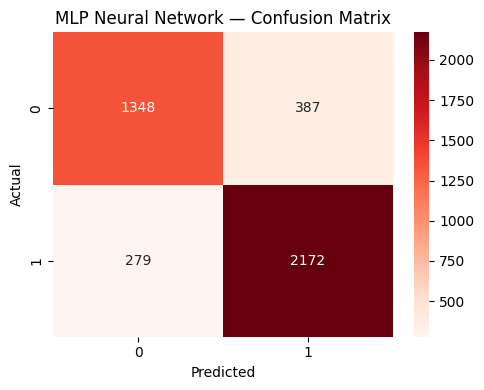

In [81]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)

evaluate('MLP Neural Network', y_test, y_pred_mlp, cmap='Reds')

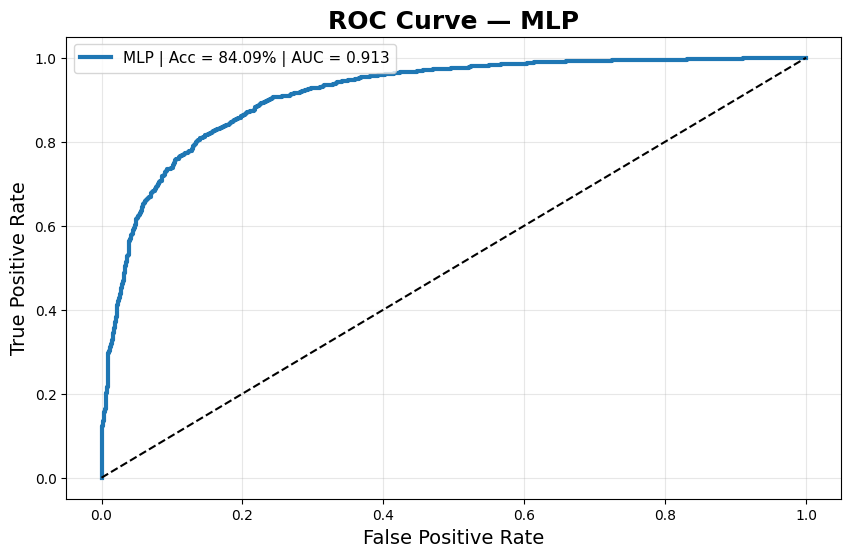

In [82]:
# ============================================================
# ROC CURVE — MLP
# ============================================================

y_pred = mlp_model.predict(X_test_scaled)

y_prob = mlp_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'MLP | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title(
    'ROC Curve — MLP',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 14. Model 6 - Stacking Ensemble



────────────────────────────────────────
  Stacking Ensemble
  Accuracy : 0.8462  (84.62%)
  Precision: 0.8550
  Recall   : 0.8878
  F1 Score : 0.8711
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1735
           1       0.86      0.89      0.87      2451

    accuracy                           0.85      4186
   macro avg       0.84      0.84      0.84      4186
weighted avg       0.85      0.85      0.85      4186



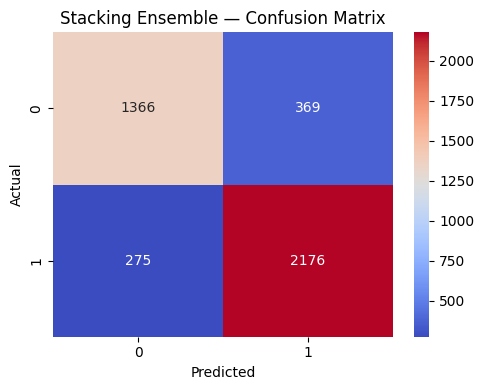

In [83]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('lr',  LogisticRegression(C=5, max_iter=1000, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=300, max_depth=None,
                                   min_samples_leaf=2, n_jobs=-1, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='logloss', n_jobs=-1, random_state=42)),
    ('svm', SVC(kernel='rbf', C=5, gamma='scale',
                probability=True, random_state=42)),
]

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(C=10, max_iter=1000),
    cv=5,
    n_jobs=-1
)
stack_model.fit(X_train_scaled, y_train)
y_pred_stack = stack_model.predict(X_test_scaled)

evaluate('Stacking Ensemble', y_test, y_pred_stack, cmap='coolwarm')

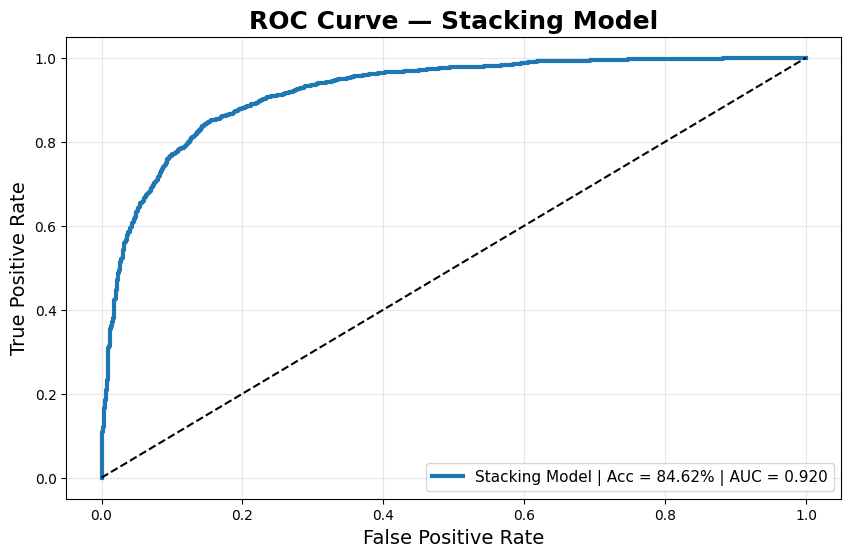

In [84]:
# ============================================================
# ROC CURVE — STACKING MODEL
# ============================================================

y_pred = stack_model.predict(X_test_scaled)

y_prob = stack_model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'Stacking Model | Acc = {accuracy:.2f}% | AUC = {roc_auc:.3f}'
)

plt.plot([0,1],[0,1], linestyle='--', color='black')

plt.title(
    'ROC Curve — Stacking Model',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=14)

plt.ylabel('True Positive Rate', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.show()

## 15. Final Comparison


=== MODEL COMPARISON (%) ===
                     Accuracy  Precision  Recall     F1
XGBoost                 84.68      86.13   88.00  87.06
Stacking Ensemble       84.62      85.50   88.78  87.11
Logistic Regression     84.43      85.97   87.73  86.84
MLP Neural Network      84.09      84.88   88.62  86.71
Random Forest           83.78      84.97   87.85  86.38
SVM                     83.61      84.65   87.94  86.27


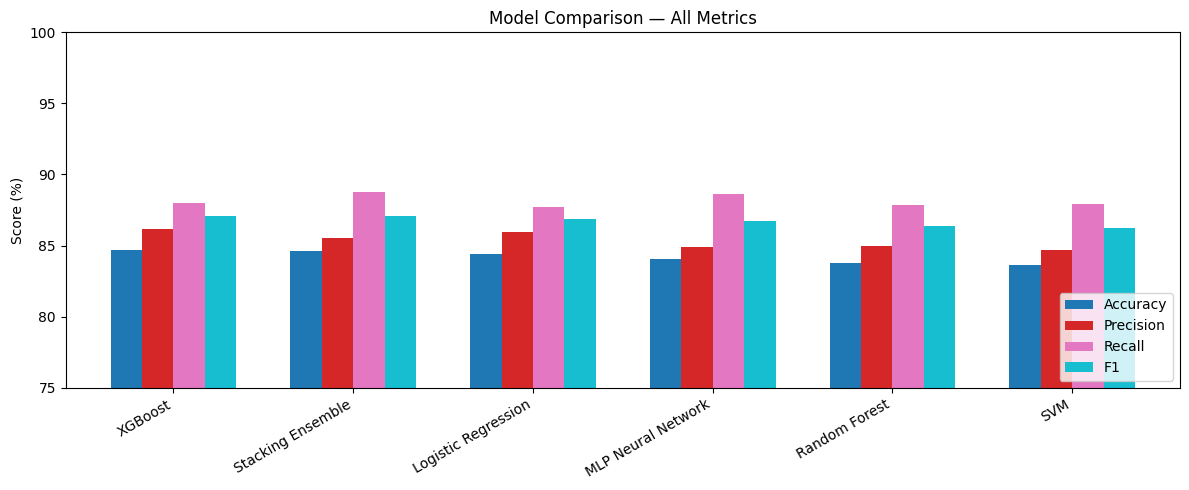

In [85]:
summary = pd.DataFrame(results).T
summary = summary.sort_values('Accuracy', ascending=False)
summary = summary * 100

print("\n=== MODEL COMPARISON (%) ===")
print(summary.round(2).to_string())

# Bar chart
ax = summary[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(12, 5), colormap='tab10', width=0.7
)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticklabels(summary.index, rotation=30, ha='right')
ax.set_ylim([75, 100])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**SAVE TRAINED MODEL FILES**

In [90]:
# ============================================================
# SAVE + AUTO DOWNLOAD MODEL FILES IN COLAB
# ============================================================

import joblib
from google.colab import files

# ------------------------------------------------------------
# SAVE MODEL
# ------------------------------------------------------------

joblib.dump(stack_model, 'student_depression_model.pkl')

# ------------------------------------------------------------
# SAVE SCALER
# ------------------------------------------------------------

joblib.dump(scaler, 'scaler.pkl')

# ------------------------------------------------------------
# SAVE FEATURE COLUMNS
# ------------------------------------------------------------

joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("All files saved successfully!")

# ============================================================
# AUTO DOWNLOAD FILES
# ============================================================

files.download('student_depression_model.pkl')

files.download('scaler.pkl')

files.download('feature_columns.pkl')

All files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Student Depression Prediction — Real-Time UI**

In [89]:
import gradio as gr
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import io

# ============================================================
# LOAD SAVED MODEL FILES
# ============================================================
model = joblib.load('/content/student_depression_model.pkl')
scaler = joblib.load('/content/scaler.pkl')
feature_columns = joblib.load('/content/feature_columns.pkl')

# ============================================================
# SHARED INPUT PROCESSOR
# ============================================================
def build_input_df(gender, age, academic_pressure, study_satisfaction,
                   sleep_duration, work_study_hours, financial_stress,
                   dietary_habits, suicidal_thoughts, family_history, cgpa):
    sleep_map = {"Less than 5 hours": 1, "5-6 hours": 2, "7-8 hours": 3, "More than 8 hours": 4}
    diet_map  = {"Unhealthy": 1, "Moderate": 2, "Healthy": 3}

    d = {
        'Gender': 1 if gender == "Female" else 0,
        'Age': age,
        'Academic Pressure': academic_pressure,
        'Study Satisfaction': study_satisfaction,
        'Sleep Duration': sleep_map[sleep_duration],
        'Work/Study Hours': work_study_hours,
        'Financial Stress': financial_stress,
        'Dietary Habits': diet_map[dietary_habits],
        'Have you ever had suicidal thoughts ?': 1 if suicidal_thoughts == "Yes" else 0,
        'Family History of Mental Illness': 1 if family_history == "Yes" else 0,
        'CGPA': cgpa
    }
    d['risk_score']       = d['Have you ever had suicidal thoughts ?'] * 3 + d['Financial Stress'] + d['Academic Pressure'] + (5 - d['Study Satisfaction'])
    d['pressure_sleep']   = d['Academic Pressure'] * d['Sleep Duration']
    d['stress_hours']     = d['Financial Stress']  * d['Work/Study Hours']
    d['pressure_satisfy'] = d['Academic Pressure'] * d['Study Satisfaction']
    d['academic_sq']      = d['Academic Pressure'] ** 2
    d['financial_sq']     = d['Financial Stress']  ** 2
    d['pressure_financial']= d['Academic Pressure'] * d['Financial Stress']
    d['holistic_stress']  = d['Academic Pressure'] + d['Financial Stress'] + d['Work/Study Hours'] - d['Study Satisfaction']
    d['suicidal_pressure']= d['Have you ever had suicidal thoughts ?'] * d['Academic Pressure']

    df_in = pd.DataFrame([d])
    for col in feature_columns:
        if col not in df_in.columns:
            df_in[col] = 0
    return df_in[feature_columns], d

# ============================================================
# PREDICTION ENGINE  (unchanged logic, same output card)
# ============================================================
def predict_depression(gender, age, academic_pressure, study_satisfaction,
                       sleep_duration, work_study_hours, financial_stress,
                       dietary_habits, suicidal_thoughts, family_history, cgpa):
    df_in, _ = build_input_df(gender, age, academic_pressure, study_satisfaction,
                               sleep_duration, work_study_hours, financial_stress,
                               dietary_habits, suicidal_thoughts, family_history, cgpa)
    scaled_input = scaler.transform(df_in)
    prediction   = model.predict(scaled_input)[0]
    probability  = model.predict_proba(scaled_input)[0][1] * 100

    if prediction == 1:
        accent = "#f43f5e"
        bg     = "linear-gradient(135deg, rgba(244,63,94,0.15), rgba(159,18,57,0.25))"
        status = "CRITICAL METRICS EXCEEDED"
        badge  = "High Risk Classification"
        desc   = "The clinical engine identified systemic distress patterns across multiple socioeconomic and lifestyle vectors. Immediate supportive intervention is strongly recommended."
    else:
        accent = "#10b981"
        bg     = "linear-gradient(135deg, rgba(16,185,129,0.15), rgba(6,78,59,0.25))"
        status = "NOMINAL METRICS DETECTED"
        badge  = "Low Risk Classification"
        desc   = "The baseline psychological and socioeconomic markers reflect standard adaptive ranges. Continue tracking regular wellness intervals."

    return f"""
    <div style='background: {bg}; border: 1px solid {accent}; backdrop-filter: blur(12px); padding: 35px; border-radius: 16px; color: white; box-shadow: 0 20px 40px -15px rgba(0,0,0,0.5);'>
        <div style='display: flex; justify-content: space-between; align-items: center; margin-bottom: 25px;'>
            <span style='font-size: 13px; font-weight: 700; color: {accent}; letter-spacing: 1.5px; text-transform: uppercase;'>{status}</span>
            <span style='background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.1); padding: 6px 14px; border-radius: 30px; font-size: 12px; font-weight: 600; color: #cbd5e1;'>{badge}</span>
        </div>
        <h3 style='font-size: 24px; font-weight: 800; color: #f8fafc; margin-bottom: 12px; letter-spacing: -0.5px;'>Diagnostic Assessment</h3>
        <p style='color: #94a3b8; font-size: 15px; line-height: 1.6; margin-bottom: 30px;'>{desc}</p>
        <div style='background: rgba(15,23,42,0.4); border: 1px solid rgba(255,255,255,0.05); padding: 20px; border-radius: 12px;'>
            <div style='display: flex; justify-content: space-between; font-size: 14px; font-weight: 600; color: #cbd5e1; margin-bottom: 10px;'>
                <span>Calculated Risk Quotient</span>
                <span style='color: {accent}; font-weight: 700;'>{probability:.2f}%</span>
            </div>
            <div style='width: 100%; background: #1e293b; height: 10px; border-radius: 20px; overflow: hidden;'>
                <div style='width: {probability}%; background: {accent}; height: 100%; border-radius: 20px;'></div>
            </div>
        </div>
    </div>
    """

# ============================================================
# ANALYTICS ENGINE  — returns 3 matplotlib figures
# ============================================================
DARK_BG   = "#030712"
CARD_BG   = "#0b0f19"
BORDER    = "#1e293b"
TEXT_MAIN = "#f8fafc"
TEXT_MUTE = "#64748b"
BLUE      = "#3b82f6"
GREEN     = "#10b981"
RED       = "#f43f5e"
AMBER     = "#f59e0b"
PURPLE    = "#a855f7"

def style_ax(ax, title):
    ax.set_facecolor(CARD_BG)
    ax.spines[['top','right','left','bottom']].set_color(BORDER)
    ax.tick_params(colors=TEXT_MUTE, labelsize=9)
    ax.set_title(title, color=TEXT_MAIN, fontsize=12, fontweight='bold', pad=12)
    ax.title.set_color(TEXT_MAIN)

def make_fig():
    fig = plt.Figure(figsize=(7, 4), facecolor=DARK_BG)
    return fig

def analytics_charts(gender, age, academic_pressure, study_satisfaction,
                     sleep_duration, work_study_hours, financial_stress,
                     dietary_habits, suicidal_thoughts, family_history, cgpa):

    df_in, d = build_input_df(gender, age, academic_pressure, study_satisfaction,
                               sleep_duration, work_study_hours, financial_stress,
                               dietary_habits, suicidal_thoughts, family_history, cgpa)
    scaled_input = scaler.transform(df_in)
    probability  = model.predict_proba(scaled_input)[0][1] * 100

    fig1 = make_fig()
    ax1  = fig1.add_subplot(111)

    factors = {
        "Academic\nPressure": d['Academic Pressure'] / 5,
        "Financial\nStress":  d['Financial Stress']  / 5,
        "Sleep\nDeprivation": 1 - (d['Sleep Duration'] / 4),
        "Poor\nDiet":         1 - (d['Dietary Habits'] / 3),
        "Study\nSatisfaction\n(inv)": 1 - (d['Study Satisfaction'] / 5),
        "Work/Study\nHours":  d['Work/Study Hours'] / 16,
    }
    labels = list(factors.keys())
    vals   = [v * 100 for v in factors.values()]
    colors = [RED if v > 60 else AMBER if v > 35 else GREEN for v in vals]

    bars = ax1.barh(labels, vals, color=colors, height=0.55, zorder=3)
    ax1.set_xlim(0, 100)
    ax1.axvline(60, color=RED,   alpha=0.3, linestyle='--', lw=1)
    ax1.axvline(35, color=AMBER, alpha=0.3, linestyle='--', lw=1)
    ax1.set_xlabel("Risk Contribution (%)", color=TEXT_MUTE, fontsize=9)
    for bar, val in zip(bars, vals):
        ax1.text(val + 1.5, bar.get_y() + bar.get_height()/2,
                 f"{val:.0f}%", va='center', color=TEXT_MAIN, fontsize=9, fontweight='bold')
    style_ax(ax1, "📊 Risk Factor Breakdown")
    ax1.grid(axis='x', color=BORDER, zorder=0)

    legend = [
        mpatches.Patch(color=RED,   label='High Risk (>60%)'),
        mpatches.Patch(color=AMBER, label='Moderate (35–60%)'),
        mpatches.Patch(color=GREEN, label='Low (<35%)'),
    ]
    ax1.legend(handles=legend, loc='lower right', facecolor=CARD_BG,
               edgecolor=BORDER, labelcolor=TEXT_MUTE, fontsize=8)
    fig1.tight_layout(pad=1.5)


    fig2 = make_fig()
    fig2.set_size_inches(5, 4)
    ax2  = fig2.add_subplot(111)
    ax2.set_facecolor(DARK_BG)
    ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-0.3, 1.3)
    ax2.axis('off')

    # draw arc segments
    import numpy as np
    theta = np.linspace(np.pi, 0, 300)
    segs  = [(0, 35, GREEN, "Low"), (35, 60, AMBER, "Moderate"), (60, 100, RED, "High")]
    for lo, hi, col, _ in segs:
        t_seg = theta[int(lo*3):int(hi*3)+1]
        ax2.plot(np.cos(t_seg), np.sin(t_seg), color=col, linewidth=18, solid_capstyle='butt', alpha=0.85)

    # needle
    angle   = np.pi * (1 - probability / 100)
    ax2.annotate("", xy=(0.72*np.cos(angle), 0.72*np.sin(angle)),
                 xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=TEXT_MAIN, lw=2,
                                 mutation_scale=20))
    ax2.plot(0, 0, 'o', color=TEXT_MAIN, markersize=8, zorder=5)

    risk_color = RED if probability > 60 else AMBER if probability > 35 else GREEN
    ax2.text(0, -0.15, f"{probability:.1f}%", ha='center', va='center',
             fontsize=28, fontweight='bold', color=risk_color)
    ax2.text(0, -0.28, "Overall Depression Risk", ha='center', va='center',
             fontsize=10, color=TEXT_MUTE)

    for lo, hi, col, label in segs:
        mid = np.pi * (1 - (lo + hi) / 200)
        ax2.text(0.92*np.cos(mid), 0.92*np.sin(mid), label,
                 ha='center', va='center', fontsize=8, color=col, fontweight='bold')

    ax2.set_title("🎯 Overall Risk Gauge", color=TEXT_MAIN, fontsize=12,
                  fontweight='bold', y=1.02)
    fig2.tight_layout(pad=1)


    fig3 = make_fig()
    fig3.set_size_inches(7, 4)
    ax3  = fig3.add_subplot(111)
    ax3.set_facecolor(DARK_BG); ax3.axis('off')

    wellness_items = {
        "😴 Sleep Quality":   min(d['Sleep Duration'] / 4 * 100, 100),
        "🥗 Diet Quality":    d['Dietary Habits'] / 3 * 100,
        "📖 Study Satisfaction": d['Study Satisfaction'] / 5 * 100,
        "🧘 Stress Resilience": max(0, 100 - d['risk_score'] / 16 * 100),
        "⏰ Work-Life Balance":  max(0, 100 - d['Work/Study Hours'] / 16 * 100),
    }

    n = len(wellness_items)
    cell_w, cell_h = 1.0 / n, 0.7
    for i, (label, score) in enumerate(wellness_items.items()):
        x = i / n
        clr = GREEN if score >= 65 else AMBER if score >= 40 else RED
        # background card
        rect = mpatches.FancyBboxPatch((x + 0.01, 0.05), cell_w - 0.03, cell_h,
                                        boxstyle="round,pad=0.02", linewidth=1,
                                        edgecolor=BORDER, facecolor=CARD_BG,
                                        transform=ax3.transAxes, clip_on=False)
        ax3.add_patch(rect)
        # score text
        ax3.text(x + cell_w/2, 0.58, f"{score:.0f}", ha='center', va='center',
                 fontsize=24, fontweight='bold', color=clr, transform=ax3.transAxes)
        ax3.text(x + cell_w/2, 0.40, "/100", ha='center', va='center',
                 fontsize=9, color=TEXT_MUTE, transform=ax3.transAxes)
        # mini bar
        bar_x  = x + 0.04
        bar_w  = cell_w - 0.08
        bar_y  = 0.20
        bar_h  = 0.07
        ax3.add_patch(mpatches.FancyBboxPatch((bar_x, bar_y), bar_w, bar_h,
                      boxstyle="round,pad=0.005", facecolor=BORDER,
                      transform=ax3.transAxes, clip_on=False))
        ax3.add_patch(mpatches.FancyBboxPatch((bar_x, bar_y), bar_w * score/100, bar_h,
                      boxstyle="round,pad=0.005", facecolor=clr, alpha=0.85,
                      transform=ax3.transAxes, clip_on=False))
        # label
        short = label.split(" ", 1)[1] if " " in label else label
        emoji = label.split(" ")[0]
        ax3.text(x + cell_w/2, 0.13, emoji, ha='center', va='center',
                 fontsize=14, transform=ax3.transAxes)
        ax3.text(x + cell_w/2, 0.06, short, ha='center', va='center',
                 fontsize=7.5, color=TEXT_MUTE, transform=ax3.transAxes,
                 wrap=True)

    ax3.set_title("💚 Wellness Score Card", color=TEXT_MAIN, fontsize=12,
                  fontweight='bold')
    fig3.tight_layout(pad=0.5)

    return fig1, fig2, fig3

# ============================================================
# REMEDY ENGINE  — severity-aware, realistic suggestions
# ============================================================
def get_remedies(gender, age, academic_pressure, study_satisfaction,
                 sleep_duration, work_study_hours, financial_stress,
                 dietary_habits, suicidal_thoughts, family_history, cgpa):

    df_in, d = build_input_df(gender, age, academic_pressure, study_satisfaction,
                               sleep_duration, work_study_hours, financial_stress,
                               dietary_habits, suicidal_thoughts, family_history, cgpa)
    scaled_input = scaler.transform(df_in)
    probability  = model.predict_proba(scaled_input)[0][1] * 100

    if probability >= 65:
        severity = "high"
    elif probability >= 38:
        severity = "moderate"
    else:
        severity = "low"

    sev_config = {
        "high":     ("#f43f5e", "🚨 High Severity — Urgent Action Recommended",
                     "Your profile indicates significant psychological distress markers. The remedies below are evidence-based priorities — not optional suggestions."),
        "moderate": ("#f59e0b", "⚠️ Moderate Severity — Proactive Intervention",
                     "Several stress vectors are elevated. Consistent application of the strategies below can meaningfully reduce your risk over 4–6 weeks."),
        "low":      ("#10b981", "✅ Low Severity — Maintenance & Prevention",
                     "Your current profile is within healthy ranges. Use these practices to maintain and strengthen your mental resilience."),
    }
    color, heading, summary = sev_config[severity]

    remedies = []


    remedies.append({
        "icon": "🧠", "title": "Cognitive Defusion (5 min/day)",
        "desc": "When a stressful thought hits, name it out loud: <em>\"I notice I'm having the thought that...\"</em> This ACT technique creates mental distance and reduces emotional reactivity. No app, no subscription — just your voice.",
        "tag": "Mental Health"
    })


    if d['Sleep Duration'] <= 2:
        remedies.append({
            "icon": "😴", "title": "Hard Sleep Cutoff — Non-Negotiable",
            "desc": "You are sleeping less than 6 hours. Set a phone alarm labeled <em>\"Brain Repair Time\"</em> for 10:30 PM. No screens 30 min before. Sleep is not a reward for finishing work — it <strong>is</strong> the work.",
            "tag": "Sleep"
        })
    else:
        remedies.append({
            "icon": "😴", "title": "Lock In a Sleep Routine",
            "desc": "Even one consistent wake time (regardless of bedtime) anchors your circadian rhythm within 5–7 days. Add a 10-minute wind-down ritual: dim lights, no social media, a glass of water.",
            "tag": "Sleep"
        })


    if d['Academic Pressure'] >= 4:
        remedies.append({
            "icon": "📚", "title": "The 2-Task Rule for High-Pressure Days",
            "desc": "Pick only 2 tasks the night before that, if completed, make tomorrow a success. Everything else is a bonus. This reduces decision fatigue and delivers the daily win your brain needs to stay motivated.",
            "tag": "Academic"
        })
    if d['Study Satisfaction'] <= 2:
        remedies.append({
            "icon": "🎯", "title": "Find the 20% That Excites You",
            "desc": "List all your current subjects/responsibilities. Circle any part — even one lecture topic — that you find genuinely interesting. Start each study session with that. Curiosity is a biological on-switch.",
            "tag": "Academic"
        })


    if d['Financial Stress'] >= 4:
        remedies.append({
            "icon": "💰", "title": "Anxiety Journaling for Financial Stress",
            "desc": "Financial anxiety grows in ambiguity. Spend 10 minutes writing: <em>What specifically worries me? What is the actual worst case? What is one thing I can control this week?</em> Most people find the written version far smaller than the mental one.",
            "tag": "Financial"
        })
        remedies.append({
            "icon": "🏫", "title": "Visit Your University's Financial Aid Office",
            "desc": "Most universities have emergency hardship funds, meal plans, and fee deferrals that are underutilised. These are not charity — they are services you are entitled to as a student. One 20-minute visit can change your semester.",
            "tag": "Financial"
        })


    if d['Dietary Habits'] == 1:
        remedies.append({
            "icon": "🥗", "title": "The One Good Meal Rule",
            "desc": "You don't need to overhaul your diet overnight. Just ensure <strong>one</strong> balanced meal daily: a protein source, complex carbs, and any vegetable. Eggs, rice and spinach. Oats and a banana. The gut-brain axis responds within days.",
            "tag": "Nutrition"
        })


    if d['Work/Study Hours'] >= 10:
        remedies.append({
            "icon": "⏳", "title": "Time-Boxing with a Real Break",
            "desc": "Work in 90-minute blocks with a mandatory 15–20 minute break — not a scroll break, an actual break: walk, stretch, make tea. Sustained focus beyond 90 min degrades output quality by ~40% (research-backed). You're already working; make it count.",
            "tag": "Productivity"
        })


    if family_history == "Yes":
        remedies.append({
            "icon": "🧬", "title": "Know Your Baseline — Track Your Mood",
            "desc": "With a family history of mental illness, awareness is your biggest asset. Use a simple 1–10 mood log each night in your phone Notes app. Patterns (3+ bad days in a row) become visible before they become crises.",
            "tag": "Preventive"
        })


    if suicidal_thoughts == "Yes":
        remedies.append({
            "icon": "🤝", "title": "Talk to Someone — This Week, Not Someday",
            "desc": "Experiencing thoughts of self-harm is a signal that your mind is overwhelmed, not that things are hopeless. Please contact your university counseling center this week. If you are in immediate distress, call a crisis helpline (iCall Pakistan: 0311-7786264). You do not have to manage this alone.",
            "tag": "Urgent"
        })

    if severity in ("high", "moderate"):
        remedies.append({
            "icon": "🚶", "title": "20-Minute Walk — The Free Antidepressant",
            "desc": "A brisk 20-minute walk raises BDNF (brain-derived neurotrophic factor), the protein your brain uses to build resilience. No gym required. Outside > inside. Morning > evening. Consistent > intense.",
            "tag": "Physical"
        })
    else:
        remedies.append({
            "icon": "🧘", "title": "Build a 5-Minute Mindfulness Habit",
            "desc": "Sit comfortably, set a 5-min timer, and focus only on your breath. When your mind wanders, return without judgment. This simple practice measurably reduces cortisol levels with 3–4 weeks of consistency.",
            "tag": "Mental Health"
        })


    remedies.append({
        "icon": "👥", "title": "Schedule One Meaningful Conversation Weekly",
        "desc": "Not a group chat message — an actual call or in-person chat with someone who matters to you. Social connection is the single strongest predictor of long-term mental wellbeing across all demographics.",
        "tag": "Social"
    })

    tag_colors = {
        "Mental Health": "#3b82f6", "Sleep": "#8b5cf6", "Academic": "#06b6d4",
        "Financial": "#f59e0b", "Nutrition": "#10b981", "Productivity": "#6366f1",
        "Physical": "#ec4899", "Social": "#14b8a6", "Preventive": "#a855f7",
        "Urgent": "#f43f5e",
    }

    cards_html = ""
    for r in remedies:
        tag_c = tag_colors.get(r["tag"], "#64748b")
        cards_html += f"""
        <div style='background:#0b0f19; border:1px solid #1e293b; border-radius:14px;
                    padding:22px; margin-bottom:14px; display:flex; gap:16px; align-items:flex-start;'>
          <div style='font-size:28px; flex-shrink:0; margin-top:2px;'>{r['icon']}</div>
          <div>
            <div style='display:flex; align-items:center; gap:10px; margin-bottom:8px;'>
              <span style='color:#f1f5f9; font-weight:700; font-size:15px;'>{r['title']}</span>
              <span style='background:{tag_c}22; color:{tag_c}; border:1px solid {tag_c}44;
                           padding:2px 10px; border-radius:20px; font-size:11px; font-weight:600;'>{r['tag']}</span>
            </div>
            <p style='color:#94a3b8; font-size:14px; line-height:1.65; margin:0;'>{r['desc']}</p>
          </div>
        </div>"""

    html = f"""
    <div style='max-width:900px; margin:0 auto;'>
      <div style='background: linear-gradient(135deg, {color}18, {color}08);
                  border:1px solid {color}44; border-radius:16px; padding:28px; margin-bottom:24px;'>
        <h2 style='color:{color}; font-size:20px; font-weight:800; margin-bottom:10px;'>{heading}</h2>
        <p style='color:#94a3b8; font-size:15px; line-height:1.6; margin:0;'>{summary}</p>
        <div style='margin-top:18px; display:flex; align-items:center; gap:12px;'>
          <div style='background:#1e293b; border-radius:20px; height:8px; flex:1; overflow:hidden;'>
            <div style='width:{probability:.1f}%; background:{color}; height:100%; border-radius:20px;'></div>
          </div>
          <span style='color:{color}; font-weight:700; font-size:16px; white-space:nowrap;'>{probability:.1f}% Risk</span>
        </div>
      </div>
      <div style='color:#64748b; font-size:11px; font-weight:700; letter-spacing:1px;
                  text-transform:uppercase; margin-bottom:14px; padding-left:4px;'>
        {len(remedies)} PERSONALISED RECOMMENDATIONS
      </div>
      {cards_html}
      <div style='margin-top:20px; padding:16px 20px; background:rgba(59,130,246,0.05);
                  border:1px solid rgba(59,130,246,0.12); border-radius:12px;
                  color:#64748b; font-size:13px; line-height:1.6;'>
        <strong style='color:#94a3b8;'>Disclaimer:</strong> These recommendations are evidence-informed
        general wellness strategies, not a medical diagnosis. If you are experiencing persistent distress,
        please consult a licensed mental health professional.
      </div>
    </div>"""
    return html

# ============================================================
# CSS  (original preserved, minor additions)
# ============================================================
custom_css = """
body, .gradio-container {
    background-color: #030712 !important;
    font-family: 'Plus Jakarta Sans', system-ui, sans-serif !important;
}
.hero-wrapper {
    text-align: center;
    padding: 70px 20px 50px 20px;
    background: radial-gradient(circle at top, rgba(37,99,235,0.12) 0%, transparent 60%);
    border-bottom: 1px solid #1f2937;
}
.hero-badge {
    background: linear-gradient(90deg, rgba(59,130,246,0.1), rgba(147,51,234,0.1));
    border: 1px solid rgba(59,130,246,0.2);
    color: #60a5fa;
    padding: 6px 16px;
    border-radius: 30px;
    font-size: 12px;
    font-weight: 600;
    letter-spacing: 0.5px;
    display: inline-block;
    margin-bottom: 20px;
}
.hero-title {
    color: #f8fafc;
    font-size: 44px;
    font-weight: 800;
    letter-spacing: -0.03em;
    line-height: 1.15;
    margin-bottom: 16px;
}
.hero-subtitle {
    color: #94a3b8;
    font-size: 18px;
    max-width: 700px;
    margin: 0 auto;
    line-height: 1.6;
}
.tabs .tab-nav {
    border-bottom: 1px solid #1f2937 !important;
    justify-content: center !important;
    gap: 12px !important;
    margin-bottom: 30px !important;
}
.tabs .tab-nav button {
    font-size: 14px !important;
    font-weight: 600 !important;
    color: #64748b !important;
    padding: 10px 24px !important;
    border-radius: 8px !important;
    transition: all 0.2s ease !important;
}
.tabs .tab-nav button.selected {
    color: #f8fafc !important;
    background: #111827 !important;
    border: 1px solid #1f2937 !important;
}
.glass-panel {
    background: #0b0f19 !important;
    border: 1px solid #1e293b !important;
    border-radius: 16px !important;
    padding: 24px !important;
    box-shadow: 0 4px 30px rgba(0, 0, 0, 0.4) !important;
}
.right-output-panel {
    min-height: 650px !important;
}
.panel-header-text {
    color: #94a3b8;
    font-size: 12px;
    font-weight: 700;
    letter-spacing: 1px;
    text-transform: uppercase;
    margin-bottom: 20px;
    border-left: 3px solid #3b82f6;
    padding-left: 10px;
}
button.action-btn-spec {
    background: linear-gradient(135deg, #3b82f6, #1d4ed8) !important;
    color: white !important;
    font-weight: 700 !important;
    border: none !important;
    padding: 16px !important;
    font-size: 15px !important;
    border-radius: 10px !important;
    box-shadow: 0 10px 25px -5px rgba(59, 130, 246, 0.4) !important;
    cursor: pointer !important;
    transition: all 0.2s cubic-bezier(0.4, 0, 0.2, 1) !important;
    width: 100%;
    text-transform: uppercase;
    letter-spacing: 0.5px;
}
button.action-btn-spec:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 15px 30px -5px rgba(59, 130, 246, 0.6) !important;
}
.info-box {
    background: #0f172a;
    border: 1px solid #1e293b;
    border-radius: 12px;
    padding: 20px;
    color: #94a3b8;
}
.info-box-title {
    color: #f1f5f9;
    font-weight: 700;
    font-size: 16px;
    margin-bottom: 8px;
}
"""

# ============================================================
# INPUT ARGS LIST — reused across all tabs
# ============================================================
def get_inputs(gender, age, academic_pressure, study_satisfaction,
               sleep_duration, work_study_hours, financial_stress,
               dietary_habits, suicidal_thoughts, family_history, cgpa):
    return (gender, age, academic_pressure, study_satisfaction,
            sleep_duration, work_study_hours, financial_stress,
            dietary_habits, suicidal_thoughts, family_history, cgpa)

# ============================================================
# APPLICATION LAYOUT
# ============================================================
with gr.Blocks(css=custom_css, theme=gr.themes.Default()) as demo:

    gr.HTML("""
        <div class='hero-wrapper'>
            <div class='hero-badge'>CLINICAL PREDICTION INSTRUMENT v2.0</div>
            <div class='hero-title'>Student Mental Health &amp; <br>Well-being Analytics Hub</div>
            <div class='hero-subtitle'>An advanced computational platform utilizing validated machine learning pipelines to evaluate multidimensional student psychological risk vectors.</div>
        </div>
    """)

    with gr.Tabs():


        with gr.TabItem("🎯 Screening & Diagnostics Dashboard"):
            with gr.Row():
                with gr.Column(scale=3):
                    with gr.Group(elem_classes="glass-panel"):
                        gr.HTML("<div class='panel-header-text'>01. Profile & Demographics</div>")
                        with gr.Row():
                            gender = gr.Dropdown(["Male", "Female"], label="Biological Sex Assignment", value="Female")
                            age    = gr.Slider(15, 40, value=22, step=1, label="Age Classification (Years)")

                    gr.HTML("<div style='margin-bottom: 15px;'></div>")

                    with gr.Group(elem_classes="glass-panel"):
                        gr.HTML("<div class='panel-header-text'>02. Academic Performance & Stress Weights</div>")
                        with gr.Row():
                            academic_pressure  = gr.Slider(1, 5, value=3, step=1, label="Perceived Academic Workload Stress (1-5)")
                            study_satisfaction = gr.Slider(1, 5, value=3, step=1, label="Institutional Satisfaction Index (1-5)")
                        with gr.Row():
                            cgpa             = gr.Slider(0.0, 4.0, value=3.0, step=0.01, label="Current Grade Point Average (CGPA Scale)")
                            work_study_hours = gr.Slider(0, 16, value=6, step=1, label="Daily Academic/Employment Commitment (Hours)")

                    gr.HTML("<div style='margin-bottom: 15px;'></div>")

                    with gr.Group(elem_classes="glass-panel"):
                        gr.HTML("<div class='panel-header-text'>03. Environmental Stressors & Physiology</div>")
                        with gr.Row():
                            financial_stress = gr.Slider(1, 5, value=3, step=1, label="Financial Insecurity Scale (1-5)")
                            sleep_duration   = gr.Dropdown(["Less than 5 hours","5-6 hours","7-8 hours","More than 8 hours"], value="7-8 hours", label="Diurnal Sleep Range")
                            dietary_habits   = gr.Dropdown(["Unhealthy","Moderate","Healthy"], value="Moderate", label="Nutritional Profile Consistency")

                    gr.HTML("<div style='margin-bottom: 15px;'></div>")

                    with gr.Group(elem_classes="glass-panel"):
                        gr.HTML("<div class='panel-header-text'>04. Clinical History & Critical Red Flags</div>")
                        with gr.Row():
                            suicidal_thoughts = gr.Radio(["Yes","No"], value="No", label="History of Acute Ideation / Crisis Support Request")
                            family_history    = gr.Radio(["Yes","No"], value="No", label="Heritable Lineage of Diagnosed Psychological Conditions")

                    gr.HTML("<div style='margin-bottom: 20px;'></div>")
                    predict_btn = gr.Button("📊 Run Clinical Risk Analysis", elem_classes="action-btn-spec")

                with gr.Column(scale=2):
                    with gr.Group(elem_classes="glass-panel right-output-panel"):
                        gr.HTML("<div class='panel-header-text'>Diagnostic Evaluation Panel</div>")
                        output_placeholder = gr.HTML("""
                            <div style='border: 1px dashed rgba(255,255,255,0.1); background: rgba(255,255,255,0.02); border-radius: 12px; padding: 60px 25px; text-align: center; color: #64748b; margin-top: 20px;'>
                                <div style='font-size: 40px; margin-bottom: 15px;'>📡</div>
                                <p style='font-size: 15px; margin-bottom: 6px; font-weight: 600; color: #94a3b8;'>Diagnostic Subsystem Idle</p>
                                <p style='font-size: 13px; color: #64748b;'>Configure patient lifestyle metrics and parameters on the left panel, then trigger calculation execution.</p>
                            </div>
                        """)

        with gr.TabItem("📈 Analytics & Risk Visualisation"):
            with gr.Group(elem_classes="glass-panel"):
                gr.HTML("<div class='panel-header-text'>Live Risk Analytics — Based on Your Current Inputs</div>")
                gr.HTML("<p style='color:#64748b; font-size:13px; margin-bottom:20px;'>Set your profile in the Screening tab, then click <strong style=\"color:#94a3b8;\">Generate Analytics</strong> to see your personalised risk breakdown.</p>")
                analytics_btn = gr.Button("📊 Generate Analytics", elem_classes="action-btn-spec")

            gr.HTML("<div style='margin-bottom:20px;'></div>")

            with gr.Row():
                chart_bar   = gr.Plot(label="Risk Factor Breakdown", elem_classes="glass-panel")
                chart_gauge = gr.Plot(label="Overall Risk Gauge",     elem_classes="glass-panel")

            gr.HTML("<div style='margin-bottom:16px;'></div>")

            with gr.Row():
                chart_wellness = gr.Plot(label="Wellness Score Card", elem_classes="glass-panel")


        with gr.TabItem("💊 Wellness Remedies & Action Plan"):
            with gr.Group(elem_classes="glass-panel"):
                gr.HTML("<div class='panel-header-text'>Personalised Severity-Based Recommendations</div>")
                gr.HTML("<p style='color:#64748b; font-size:13px; margin-bottom:20px;'>Remedies are tailored to your exact risk profile — not generic advice. Set your inputs in the Screening tab first.</p>")
                remedies_btn = gr.Button("💡 Generate My Action Plan", elem_classes="action-btn-spec")

            gr.HTML("<div style='margin-bottom:20px;'></div>")
            remedies_out = gr.HTML()

        with gr.TabItem("📖 Educational Infrastructure & Clinical Metadata"):
            with gr.Group(elem_classes="glass-panel"):
                gr.HTML("""
                    <div class='panel-header-text'>Understanding Predictive Clinical Modeling Weights</div>
                    <div style='display: grid; grid-template-columns: 1fr 1fr; gap: 20px; margin-top: 10px;'>
                        <div class='info-box'>
                            <div class='info-box-title'>📚 1. The Sleep-Pressure Correlation Matrix</div>
                            <p style='font-size: 14px; line-height: 1.5;'>Sleep deprivation undermines neuroplasticity and emotional regulation. When compounded by severe academic pressure, the degradation of restorative REM metrics scales risks dramatically.</p>
                        </div>
                        <div class='info-box'>
                            <div class='info-box-title'>💸 2. Financial Strain & Autonomic Load</div>
                            <p style='font-size: 14px; line-height: 1.5;'>Socioeconomic insecurity shifts active cognitive focus toward raw biological survival. This triggers a persistent physiological fight-or-flight response, minimizing capacity for academic engagement.</p>
                        </div>
                        <div class='info-box'>
                            <div class='info-box-title'>🧬 3. Genetic Predisposition & Baseline Resilience</div>
                            <p style='font-size: 14px; line-height: 1.5;'>Heritable history sets fundamental neurotransmitter regulation levels. When external lifestyle stressors increase, individuals with family clinical vectors hit critical thresholds faster.</p>
                        </div>
                        <div class='info-box'>
                            <div class='info-box-title'>🍏 4. Nutritional System Interdependency</div>
                            <p style='font-size: 14px; line-height: 1.5;'>The gut-brain axis relies completely on sound nutritional patterns. Irregular or sub-optimal systemic intake directly halts the synthesis of core regulatory neurotransmitters like serotonin.</p>
                        </div>
                    </div>
                    <div style='margin-top: 30px; padding: 20px; background: rgba(59,130,246,0.05); border: 1px solid rgba(59,130,246,0.1); border-radius: 12px; color: #94a3b8; font-size: 14px;'>
                        <strong>Institutional Screening Disclaimer:</strong> This platform performs screening analytics based strictly on structural models. It does not provide medical verdicts or diagnoses. Results should serve as early-warning data triggers for certified professional counseling workflows.
                    </div>
                """)


    all_inputs = [
        gender, age, academic_pressure, study_satisfaction,
        sleep_duration, work_study_hours, financial_stress,
        dietary_habits, suicidal_thoughts, family_history, cgpa
    ]


    predict_btn.click(
        fn=predict_depression,
        inputs=all_inputs,
        outputs=output_placeholder
    )
    analytics_btn.click(
        fn=analytics_charts,
        inputs=all_inputs,
        outputs=[chart_bar, chart_gauge, chart_wellness]
    )
    remedies_btn.click(
        fn=get_remedies,
        inputs=all_inputs,
        outputs=remedies_out
    )

# ============================================================
# LAUNCH
# ============================================================
if __name__ == "__main__":
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1a6388ebe966175ed3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
